# VIX Regime-Based Dynamic Allocation

A **VIX regime-switching** strategy that toggles between risk-on and risk-off allocations
based on VIX levels, using a parent/child portfolio tree.

- **Low-vol regime** (VIX below 20): 70% QQQ / 20% BIL / 10% GLD (risk-on)
- **High-vol regime** (VIX above 30): 40% QQQ / 40% BIL / 20% GLD (risk-off)
- **Between 20–30**: hysteresis (stick with current regime)

This notebook demonstrates:
- `Signal.VIX` for regime-based switching
- Parent/child portfolio tree architecture
- `Weigh.Ratio` for different regime allocations
- Comparison against static allocation baselines

**Offline mode**: Uses local CSV files — no network required.

In [1]:
from pathlib import Path

import tiportfolio as ti

_DATA_DIR = Path("../../tests/data")

CSV_DATA: dict[str, str] = {
    "QQQ": str(_DATA_DIR / "qqq_2018_2024_yf.csv"),
    "BIL": str(_DATA_DIR / "bil_2018_2024_yf.csv"),
    "GLD": str(_DATA_DIR / "gld_2018_2024_yf.csv"),
    "^VIX": str(_DATA_DIR / "vix_2018_2024_yf.csv"),
}

TICKERS = ["QQQ", "BIL", "GLD"]
START = "2019-01-01"
END = "2024-12-31"

## 1. Load Data

Price data for QQQ/BIL/GLD and VIX data are loaded separately.
VIX data is passed to `Signal.VIX` to drive regime switching — it is not traded.

In [2]:
data = ti.fetch_data(TICKERS, start=START, end=END, csv=CSV_DATA)
vix_data = ti.fetch_data(["^VIX"], start=START, end=END, csv=CSV_DATA)

for ticker, df in data.items():
    print(f"{ticker}: {df.shape[0]} rows")
print(f"^VIX: {vix_data['^VIX'].shape[0]} rows")

QQQ: 1760 rows
BIL: 1760 rows
GLD: 1760 rows
^VIX: 1760 rows


## 2. VIX Regime Strategy

The strategy uses a **parent/child tree** architecture:
- **Parent**: fires `Signal.VIX` to detect regime changes, then allocates to one of two children
- **low_vol child**: risk-on allocation (heavy QQQ)
- **high_vol child**: risk-off allocation (heavy BIL + GLD)

`Signal.VIX(high=30, low=20)` implements hysteresis:
- Switches to high_vol when VIX crosses **above 30**
- Switches back to low_vol when VIX drops **below 20**
- Between 20–30, the current regime persists

In [3]:
low_vol = ti.Portfolio(
    "low_vol",
    [
        ti.Select.All(),
        ti.Weigh.Ratio(weights={"QQQ": 0.7, "BIL": 0.2, "GLD": 0.1}),
        ti.Action.Rebalance(),
    ],
    TICKERS,
)

high_vol = ti.Portfolio(
    "high_vol",
    [
        ti.Select.All(),
        ti.Weigh.Ratio(weights={"QQQ": 0.4, "BIL": 0.4, "GLD": 0.2}),
        ti.Action.Rebalance(),
    ],
    TICKERS,
)

vix_regime = ti.Portfolio(
    "vix_regime",
    [
        ti.Signal.Monthly(),
        ti.Signal.VIX(high=30, low=20, data=vix_data),
        ti.Action.Rebalance(),
    ],
    [low_vol, high_vol],
)

In [4]:
result = ti.run(ti.Backtest(vix_regime, data))

## 3. Results

In [5]:
result.summary()

,value
sharpe,0.687
calmar,0.632
sortino,0.923
max_drawdown,-0.209
cagr,0.132
risk_free_rate,0.040
total_return,1.382
kelly,5.041
final_value,23815.691
total_fee,2.260


In [6]:
result.plot_interactive()

In [7]:
result.full_summary()

,value
sharpe,0.687
calmar,0.632
sortino,0.923
max_drawdown,-0.209
cagr,0.132
risk_free_rate,0.040
total_return,1.382
kelly,5.041
final_value,23815.691
total_fee,2.260


## 4. Baseline Comparisons

Compare the VIX regime strategy against:
1. **QQQ Only** — 100% QQQ buy-and-hold
2. **Fixed 70/20/10** — static monthly rebalance (the low-vol allocation, always)

In [8]:
qqq_only = ti.Portfolio(
    "qqq_only",
    [ti.Signal.Once(), ti.Select.All(), ti.Weigh.Equally(), ti.Action.Rebalance()],
    ["QQQ"],
)

fixed_monthly = ti.Portfolio(
    "fixed_70_20_10",
    [
        ti.Signal.Monthly(),
        ti.Select.All(),
        ti.Weigh.Ratio(weights={"QQQ": 0.7, "BIL": 0.2, "GLD": 0.1}),
        ti.Action.Rebalance(),
    ],
    TICKERS,
)

comparison = ti.run(
    ti.Backtest(vix_regime, data),
    ti.Backtest(qqq_only, data),
    ti.Backtest(fixed_monthly, data),
)

In [9]:
comparison.summary()

,vix_regime,qqq_only,fixed_70_20_10
sharpe,0.687,0.684,0.642
calmar,0.632,0.547,0.546
sortino,0.923,0.889,0.833
max_drawdown,-0.209,-0.351,-0.264
cagr,0.132,0.192,0.144
risk_free_rate,0.040,0.040,0.040
total_return,1.382,2.411,1.559
kelly,5.041,2.835,3.784
final_value,23815.691,34106.625,25588.316
total_fee,2.260,0.233,0.939


In [10]:
comparison.plot_interactive()

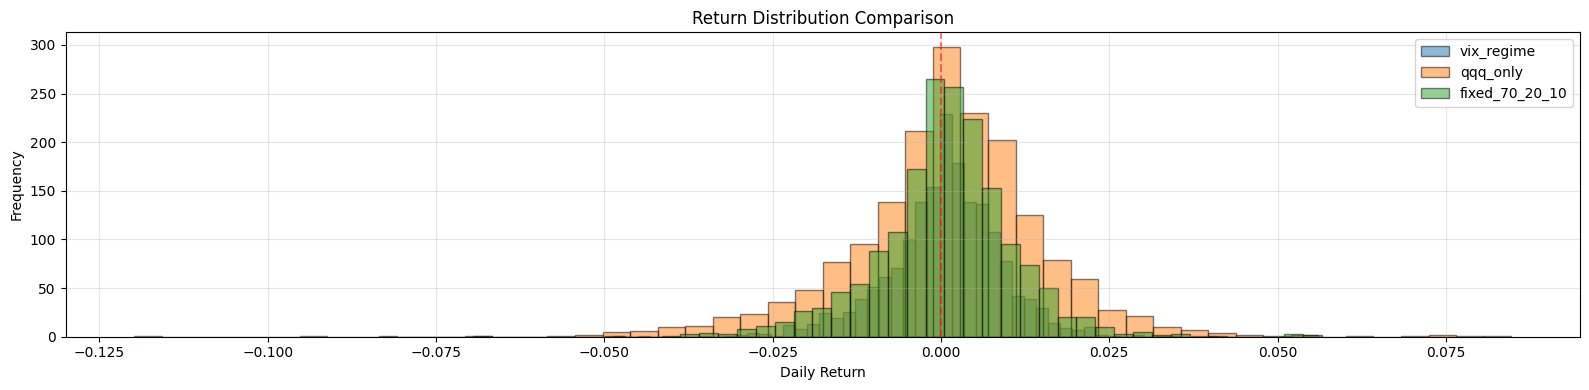

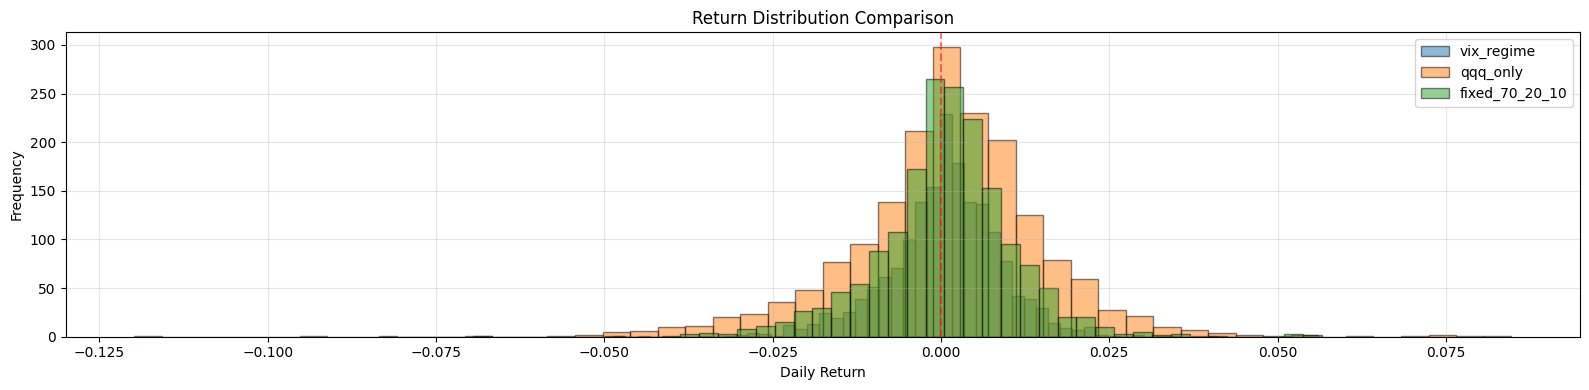

In [11]:
comparison.plot_histogram()